In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
</div>

In [1]:
# Basic everyday packages
import time
import numpy  as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.style.use('ggplot')
rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

In [2]:
from scipy.special import spence

In [3]:
import mpmath as mp
mp.dps = 50 #2*50 + 30
mp.mp.dps = 50 #2*50 + 30
print(mp.mp)

# Basic constants
n_0 = mp.mpf('0.0');    n_1 = mp.mpf('1.0');    n_2 = mp.mpf('2.0');    n_3 = mp.mpf('3.0');    n_4 = mp.mpf('4.0')

Mpmath settings:
  mp.prec = 169               [default: 53]
  mp.dps = 50                 [default: 15]
  mp.trap_complex = False     [default: False]


$\newcommand{\dif}{\,\mathrm{d}}$
We are interested in computing
\begin{align*}
    G(a;\phi) \big|_{\phi = \Phi(\theta)} = 2 \Im \big( \operatorname{Li}_2 (-a e^{2i\phi}) \big)
	+ (1-a^2) \left[ 2 \phi - \arctan\left(\frac{ a \sin 2\phi}{1 + a \cos 2\phi} \right)  \right]
	+ a\big( 2- \log(1+ a^2 +2a\cos 2\phi)  \big)\sin 2\phi 
    %= \int_0^\phi s^2(\theta) \big( 2 \log { \big| s(\theta)} \big| - 1 \big) \dif \theta
\end{align*}
for $a \in [1-\varepsilon,1+\varepsilon]$. In particular, we want to evaluate $G$ where $\phi = \Phi(\varphi)$ with
\begin{align*}
    \varphi &= \arccos \left( \frac{1 - a^2 - \varepsilon^2}{2 a \varepsilon} \right),
    &
    s(\theta) &= -a \cos(\theta) + \sqrt{1 - a^2 \sin^2(\theta)},
    &
    L(\theta)& = \frac{s^2(\theta) - 1- a^2 }{2a},
    &
    \Phi(\theta) &= \frac{1}{2} \arccos L(\theta).
\end{align*}
We observe that $\Phi(\theta) \in \left[0, \frac \pi 2\right]$, for we do not need to worry about branch cuts for $2\phi > \pi$. However, it is important to realise that $\Phi$ is not continuous for $a >1$. 

Let $\alpha = \arcsin(1/a)$, then $\Phi$ is defined only over the intervals $[k\pi - \alpha, k\pi + \alpha ]$. However, $\varphi$ takes values in $[0,2\pi]$ (particularly $\varphi|_{a=\sqrt{1-\varepsilon^2}} = \arccos 0 = \frac{\pi}{2}$). Notwithstanding, the interval of existence also moves with $a$. As a result, we have that $\varphi$ always lies in the interval of existence of $\Phi$ with $\Phi(\varphi) \geq \pi - \alpha$ for $a \geq 1$.

The quantity $G$ is an indefinite integral of $s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big)$, for which we write the alternative form
\begin{align*}
    g(a;\theta) = \int s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) \dif \theta.
\end{align*}

Here, let us define 
\begin{align*}
    f(\theta) = 
    \begin{cases}
        s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) & \text{if } \theta \in [k\pi - \alpha, k\pi +\alpha], k\in \mathbb{Z},
        \\
        0 & \text{otherwise}.
    \end{cases}
\end{align*}
It is not difficult to find that 
\begin{align*}
    s(\theta) \in 
    \begin{cases}
        \left[-\sqrt{a^2 - 1}, 1-a \right] & \text{if } k = 0 \mod 2,
        \\
        \left[\sqrt{a^2 - 1}, 1+a \right] & \text{if } k = 1 \mod 2,
        \\
        \{0\} & \text{otherwise}.
    \end{cases}
\end{align*}
In particular, the maxima of $s$ are located at $\{2\pi k: k \in \mathbb{Z}\} \cup \{ \pi k: k \in \mathbb{Z} \}$. Thus 
\begin{align*}
    f(\theta) \in 
    \begin{cases}
    \begin{cases}
        \left[ (a^2 -1) \big(\log(a^2 -1)-1\big), (a-1)^2 \big(\log(a-1)^2 -1\big)  \right] & \text{if } k = 0 \mod 2,
        \\
        \left[-1, (a+1)^2 \big(\log(a+1)^2 -1\big) \right] & \text{if } k = 1 \mod 2,
        \\
        \{0\} & \text{otherwise}.
    \end{cases}
        & \text{if } a \leq \sqrt{2},
        \\[1em]
    \begin{cases}
        \left[ -1, (a-1)^2 \big(\log(a-1)^2 -1\big)  \right] & \text{if } k = 0 \mod 2,
        \\
        \left[(a^2 -1) \big(\log(a^2 -1)-1\big), (a+1)^2 \big(\log(a+1)^2 -1\big) \right] & \text{if } k = 1 \mod 2,
        \\
        \{0\} & \text{otherwise}.
    \end{cases}
        & \text{otherwise}.
    \end{cases}
\end{align*}

As a result, $f$ is a periodic function of period $2\pi$.

In what follows, we will be interested in the case $a \leq \sqrt{2}$ since we expect $a \in [1\mp\varepsilon]$ and $\varepsilon \ll 1$. 

---
In this notebook, we will explore how to compute $G$ and compare it against $g$. In particular, we will focus on four particular subsets of values:

1. $a \in \left[1-\varepsilon, 1\right)$ with $\varphi \in \left[0, \arccos -\frac{\varepsilon}{2} \right)$,
2. $a = 1$ with $\varphi = \arccos -\frac{\varepsilon}{2}$,
3. $a \in \left(1, \sqrt{1+\varepsilon^2}\right)$ with $\varphi \in \left(\arccos -\frac{\varepsilon}{2}, \arccos -\frac{\varepsilon}{\sqrt{1+\varepsilon^2}} \right)$,
4. $a \in \left[\sqrt{1+\varepsilon^2}, 1+\varepsilon\right]$ with $\varphi \in \left[\frac{\pi}{2}, 2\pi \right]$,

---

# Continuous case $a \in \left[1-\varepsilon, 1\right)$ with $\varphi \in \left[0, \arccos -\frac{\varepsilon}{2} \right)$

Here $f$ is continuous and $G$ lies inside a single branch. We can test 
\begin{align*}
    G(a,\Phi(\varphi)) - G(a,\Phi(0)) &=
    G(a,\Phi(\varphi)) - G(a,\pi/2) 
    \\
    &= g(a;\varphi) - g(a;0)  = \int_0^\varphi s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) \dif \theta.
\end{align*}

Additionally, we have that $G(a,\pi/2) = (1-a^2) \pi$.

In [4]:
def s(a, θ):
    # Stable computation of s(θ)
    sinθ, cosθ = mp.sin(θ), mp.cos(θ)
    if θ == n_0:
        sinθ, cosθ = n_0, n_1
    elif n_2 * θ == mp.pi:
        sinθ, cosθ = n_1, n_0
    elif n_2 * θ == mp.mpf('3.0') * mp.pi:
        sinθ, cosθ = -n_1, n_0
    elif θ == mp.pi:
        sinθ, cosθ = n_0, -n_1
    elif θ == n_2 * mp.pi:
        sinθ, cosθ = n_0, n_1
    elif (mp.sin(θ) * a == n_1) and (a > n_1):
        if cosθ < n_0:
            sinθ, cosθ = n_1/a, -mp.sqrt(a*a-n_1)/a            # π - α
        else:
            sinθ, cosθ = n_1/a,  mp.sqrt(a*a-n_1)/a            # α
    elif (mp.sin(θ) * a == -n_1) and (a > n_1):
        sinθ, cosθ = -n_1/a, mp.sqrt(a*a-n_1)/a                # 2π - α
        
        
        
    R = n_1 - (a*a)*(sinθ * sinθ)
    if (abs(mp.sin(θ)) * a == n_1) and (a>n_1):
        R = n_0
    
    # Trim under precision
    if R < -mp.mpf('10')**-(mp.dps-2):
        return n_0
        
    # Clip and process
    if abs(R) <= mp.mpf('10')**-(mp.dps-2):
        s_out = -a * cosθ
    else:
        s_out = -a * cosθ + mp.sqrt(R)    
    
    if a == n_1:
        if cosθ >= n_0:
            s_out = n_0
        else:
            s_out = -n_2 * cosθ
    return s_out
def f(a,θ):
    s_aθ = s(a, θ)
    if s_aθ == n_0:
        return n_0
    return (s_aθ * s_aθ) * (n_2 * mp.log(abs(s_aθ)) - n_1)
def φ_from(a,ε):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    
    cos  = n_1 - a*a - ε*ε
    cos /= n_2 * a * ε
    
    # Special cases
    if a == n_1 - ε:              # cos φ = 1
        return n_0
    elif a == n_1 + ε:            # cos φ = -n_1
        return mp.pi
    elif mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):    #a*a == n_1 + ε*ε:        # cos φ = -ε/mp.sqrt(1 + ε^2)
        #return mp.acos(-ε/mp.sqrt(n_1 + ε*ε))
        return mp.atan(ε) + mp.pi/n_2
    elif mp.almosteq(a*a, n_1 - ε*ε, abs_eps = þ):    #a*a == n_1 - ε*ε:        # cos φ = n_0
        return mp.pi/n_2
    elif a == n_1:                # cos φ = -ε/2
        return mp.acos(-ε/n_2)
        
    return mp.acos(cos)
def Φ(a, θ):
    '''
        Variable transformation
    '''
    sθ = s(a, θ)
    Lθ = (sθ * sθ - n_1 - a*a)/(n_2 * a)        # Range [-1,1]
    if a == n_1:
        Lθ = (sθ * sθ / n_2) - n_1
    ϕ  = mp.acos(Lθ) / n_2                      # Range [0,π/2]
    return ϕ

In [5]:
# High-precision version
def G_mp_a(a,ϕ):

    '''
        Angular quantities
    '''
    cosϕ, cos2ϕ, sin2ϕ = mp.cos(ϕ), mp.cos(n_2 * ϕ), mp.sin(n_2 * ϕ)
    if (n_2 * ϕ == mp.pi):
        cosϕ, cos2ϕ, sin2ϕ = n_0, -n_1, n_0
    if (ϕ == n_0):
        cosϕ, cos2ϕ, sin2ϕ = n_1, n_1, n_0
    
    '''
        Special cases
    '''
    # G(1;ϕ)
    if (a == n_1):
        if cosϕ == n_0:
            return n_0
        else:
            G  = n_2 * mp.polylog(2, -mp.exp(2j * ϕ)).imag
            G += n_2 * (n_1 - mp.log( n_2 * abs(cosϕ) ) ) * sin2ϕ
            return G
    
    # G(a;π/2)
    '''if (n_2 * ϕ == mp.pi):
        G = (n_1 - a*a) * mp.pi
        if a > 1:
            G -= n_2 * mp.pi * mp.log(a)   # Im Li2(a) = -π log a  for a>1
        return G/(ε*ε*2*mp.log(ε)) if scale else G'''
    # G(a; 0)
    if ϕ == n_0:
        return n_0
    
    '''
        General case
    '''
    # Dilog term
    z   = -a * mp.exp(2j * ϕ)
    T_1 = n_2 * mp.polylog(2, z).imag
    
    # Angular term
    if sin2ϕ == n_0:
        α = n_0
    else:
        #α = mp.atan2(a * sin2ϕ, n_1 + a * cos2ϕ)
        #α = mp.atan( (a * sin2ϕ) / (n_1 + a * cos2ϕ))
        #mp.arg(1 + a * mp.exp(2j * ϕ))
        α = mp.arg(1 - z)
        #print(α)
    T_2 = (n_1 - a*a) * (n_2 * ϕ - α)
    
    # Log term
    l_a = (a - n_1)*(a - n_1)  + n_4 * a * (cosϕ*cosϕ)   # stable version of n_1 + a*a + n_2 * a * cos2ϕ
    T_3 = a * (n_2 - mp.log(l_a) ) * sin2ϕ
    if sin2ϕ == n_0:
        T_3 = n_0
    
    # Collect terms:
    G  = T_1 + T_2 + T_3
    
    return G
def Test_Ae(a,ε):
    '''
        Variable transformation
    '''
    θ  = φ_from(a,ε)
    ϕ  = Φ(a, φ_from(a,ε) )
    ϕₒ = np.pi/n_2                # Φ(a, n_0 )
    
    '''
        Functional evaluation
    '''
    # It can be proven that G_mp_a(a,ϕₒ) = (1-a^2) π (and if a>1 the additional 2 π log(a) is added)
    #T = G_mp_a(a,ϕ) - G_mp_a(a,ϕₒ)
    T = G_mp_a(a,ϕ) - (1-a*a)*mp.pi
    
    return T
# Numerical quadrature
def G_by_integral_A(a, ϕ):
    # One interval of existence
    A = mp.quad(lambda θ: f(a, θ), [n_0, ϕ], method='gauss-legendre' )
    return A
def Test_An(a,ε):
    # Find angle
    θ  = φ_from(a,ε)
    # Evaluate integral
    T = G_by_integral_A(a, θ)
    
    return T

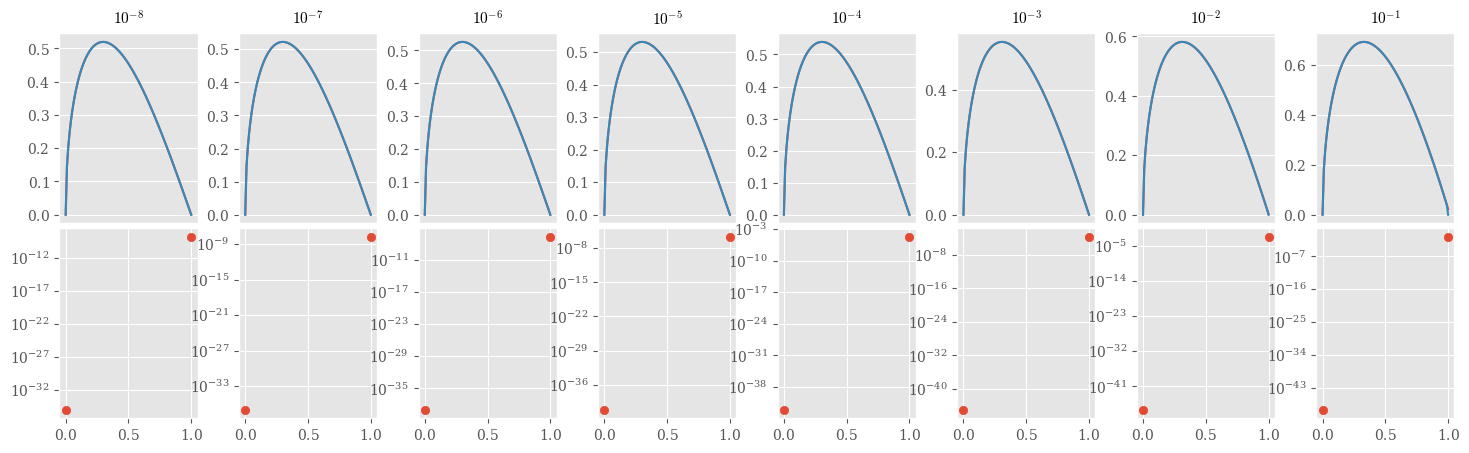

In [6]:
# Test
N = 100                                              # Number of points
Λ = mp.linspace(n_0, n_1, N)
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version

nA = np.arange(30,0,-1)[-8:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))


fig, ax = plt.subplots(nrows=2, ncols=len(E_mp), figsize = (18,5))
i = 0
for i in range(len(E_mp)):
    ε = E_np[i]
    A = [n_1 - ε * (n_1 - λ)  for λ in Λ]

    H_e_mp = [Test_Ae(a,ε) / (ε * ε * 2 * mp.log(ε)) for a in A]    # Exact
    H_n_mp = [Test_An(a,ε) / (ε * ε * 2 * mp.log(ε)) for a in A]    # Numeric
    # NumPy version
    H_e_np = np.fromiter((np.float64(x) for x in H_e_mp), dtype=np.float64, count=N)
    H_n_np = np.fromiter((np.float64(x) for x in H_n_mp), dtype=np.float64, count=N)
    
    ax[i // 8,i % 8].plot(Λ_np, H_e_np)
    ax[i // 8,i % 8].plot(Λ_np, H_n_np)
    
    ax[1, i % 8].scatter(Λ_np, abs(H_e_np - H_n_np))
    #ax[i // 8,i % 8].plot(Λ_np, H_float_yes_asy, '--', c='black')
    ax[i // 8,i % 8].set_title(leg[i], {'fontsize':11})
    #ax[i // 8,i % 8].axvline(x=λₓ, color='black', linestyle = ':')
    
    ax[1,i % 8].set_yscale('log')
    ax[0,i % 8].set_xticks([])

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.025)

Errors accumulate at end points. Elsewhere, the integral is exact under the current precision.

---

# Case $a = 1$ with $\varphi = \arccos -\frac{\varepsilon}{2}$

Here, let $\alpha = \arcsin \frac{1}{a} = \frac{\pi}{2}$. Now, $f$ is continuous inside $[\pi-\alpha,\varphi]$. Now we aim to showcase
\begin{align*}
    G(1,\Phi(\varphi)) - G(1,\Phi(\pi-\alpha)) &=
    G(1,\Phi(\varphi)) - G(1,\pi/2) 
    \\
    &= g(1;\varphi) - g(1;\pi-\alpha)  = \int_{\pi-\alpha}^\varphi s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) \dif \theta.
\end{align*}

We can showcase the region of integration limited by $\varphi \leq \frac{2}{3}\pi = \arccos -\frac{1}{2}$:

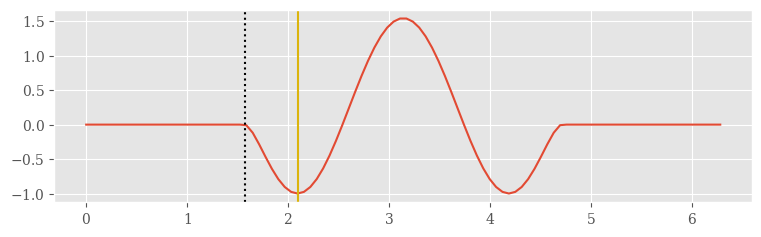

In [7]:
# Integration bits
plt.figure(figsize = (9,2.5))
plt.plot(mp.linspace(n_0, n_2*mp.pi, N), [f(n_1,x) for x in mp.linspace(n_0, n_2*mp.pi, N) ])
plt.axvline(x=mp.pi/2, color='black', linestyle = ':')
plt.axvline(x=φ_from(n_1,n_1), color='xkcd:gold')
plt.show()

Observe that $s(\theta) = \begin{cases} 0 & \text{if } \cos \theta \geq 0, \\ -2\cos \theta & \text{otherwise.}  \end{cases}$ and thus 
\begin{align*}
    0 > \int_{\pi/2}^\varphi s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) \dif \theta = 
    \int_{\pi/2}^\varphi 4 \cos^2 \theta \left( \log (4 \cos^2 \theta) -1 \right) \dif \theta 
    \geq 
    \int_{\pi/2}^{2\pi /3} 4 \cos^2 \theta \left( \log (4 \cos^2 \theta) -1 \right) \dif \theta 
    %\sqrt{3} - 2 Cl_2 (\pi/3)
    = \sqrt{3} - 2\Im\operatorname{Li}_2 ( e^{i \pi /3} )
    \approx -0.297832.
\end{align*}
Where we used the fact that $\frac{\pi}{2} < \arccos -\frac{\varepsilon}{2} = \varphi \leq \frac{2}{3}\pi = \arccos - \frac{1}{2}$, where the former inequality comes from the fact that $\varphi|_{a = \sqrt{1-\varepsilon^2}} = \frac{\pi}{2}$, [[1]](https://chat.deepseek.com/share/fdl5hl8du0a764r1t9).

In fact, we can prove that [[2]](https://chat.deepseek.com/share/j6ghlpvck59xpb1utc):
\begin{align*}
    \int_{\pi/2}^\varphi s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) \dif \theta
    \approx
    \frac{1}{3} \varepsilon^3 \log \varepsilon - \frac{5}{18} \varepsilon^3 + O(\varepsilon^5 \log \varepsilon) .
\end{align*}
Already by $\varepsilon = 10^{-5}$, the integral would be below machine precision (double).

In [8]:
mp.sqrt(3) - 2 * mp.polylog(2, mp.exp(1j*mp.pi/3)).imag

mpf('-0.29783240525042995651495876704316820494057336125021668')

On the other hand
\begin{align*}
    G(1;\phi) = 
    2\Im \operatorname{Li}_2 \big(-e^{2i\phi}\big) + 2\big(1 - \log\big(2 |\cos \phi|\big)\big) \sin 2\phi
    \qquad\text{and}\qquad
    G(1;\pi/2) =  0.
\end{align*}

In [9]:
mp.dps = 50 #2*50 + 30
mp.mp.dps = 50 #2*50 + 30
print(mp.mp)
mp.dps = 2*50 + 30
mp.mp.dps = 2*50 + 30
print(mp.mp)

Mpmath settings:
  mp.prec = 169               [default: 53]
  mp.dps = 50                 [default: 15]
  mp.trap_complex = False     [default: False]
Mpmath settings:
  mp.prec = 435               [default: 53]
  mp.dps = 130                [default: 15]
  mp.trap_complex = False     [default: False]


In [10]:
# Numerical quadrature
def G_by_integral_B(ϕ):
    #α = mp.asin(n_1/n_1)
    α = mp.pi/n_2
    # One interval of existence
    #A = mp.quad(lambda θ: f(a, θ), [mp.pi - α, ϕ], method='gauss-legendre' )
    A = mp.quad(lambda θ: f(n_1, θ), [α, ϕ], method='gauss-legendre' )
    return A
def Test_Bn(ε):
    # Find angle
    θ  = φ_from(n_1,ε)
    # Evaluate integral
    T = G_by_integral_B(θ)
    
    return T

In [11]:
nA = np.arange(30,0,-1)[:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]

In [12]:
# plt.plot([G_mp_a(n_1,x) for x in mp.linspace(n_0, n_2*mp.pi, 100)])        # This is G(1,x)
G_Be  = [G_mp_a(n_1, Φ(n_1, φ_from(n_1,ε) ) ) for ε in E_mp]
G_Bn  = [Test_Bn(ε) for ε in E_mp]
G_Bas = [ ε*ε*ε * mp.log(ε) /mp.mpf('3.0') - mp.mpf('5.0') * (ε*ε*ε) / mp.mpf('18.0') for ε in E_mp]

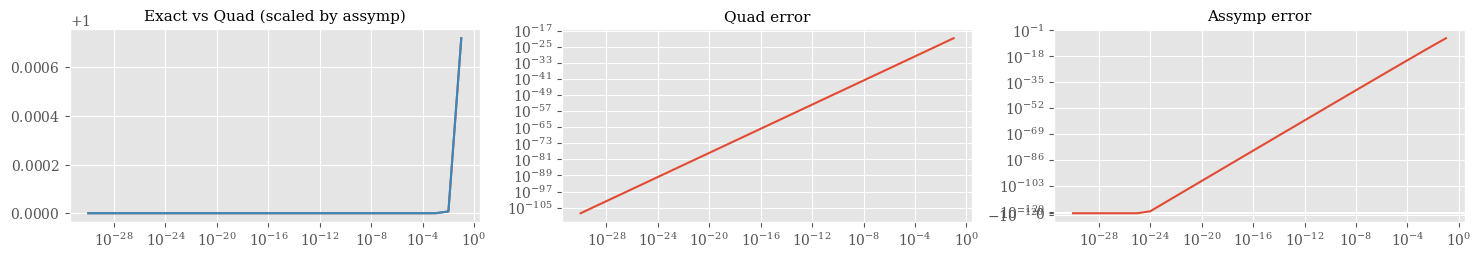

In [13]:
# Test
fig, ax = plt.subplots(nrows=1, ncols=3, figsize = (18,2.5))

ax[0].plot(E_mp, np.asarray(G_Be)/G_Bas)
ax[0].plot(E_mp, np.asarray(G_Bn)/G_Bas)
#ax[0].plot(E_mp, G_Bas)
ax[0].set_title('Exact vs Quad (scaled by assymp)', {'fontsize':11})

ax[1].plot(E_mp, abs(np.asarray(G_Be) - G_Bn) )
ax[1].set_title('Quad error', {'fontsize':11})

ax[2].plot(E_mp, abs(np.asarray(G_Be) - G_Bas) )
ax[2].set_title('Assymp error', {'fontsize':11})

#ax[0].set_yscale('symlog', linthresh=1e-92)
ax[1].set_yscale('symlog', linthresh=1e-120)
ax[2].set_yscale('symlog', linthresh=1e-120)
for i in range(3):
    ax[i].set_xscale('log')

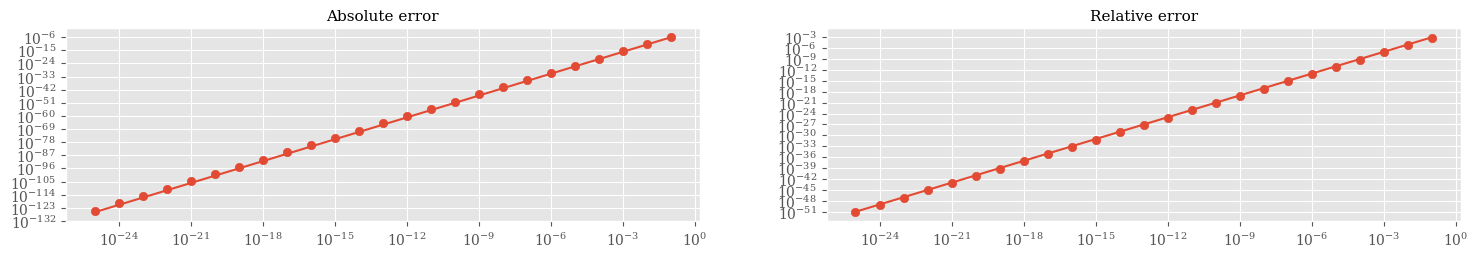

In [14]:
# Errors
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (18,2.5))

ax[0].scatter(E_mp[5:], (abs(np.asarray(G_Be) - G_Bas))[5:] )
ax[0].plot(E_mp[5:], np.asarray(E_mp[5:])**5 * 0.1 )
ax[0].set_title('Absolute error', {'fontsize':11})

ax[1].scatter(E_mp[5:], (abs(np.asarray(G_Be) - G_Bas) / abs(np.asarray(G_Be)) )[5:] )
ax[1].plot(E_mp[5:], np.asarray(E_mp[5:])**2 * 0.1 )
ax[1].set_title('Relative error', {'fontsize':11})


#ax[0].set_yscale('symlog', linthresh=1e-92)
ax[0].set_yscale('symlog', linthresh=1e-180)
ax[1].set_yscale('symlog', linthresh=1e-120)
for i in range(2):
    ax[i].set_xscale('log')

In [15]:
x = np.asarray([mp.log(a) for a in E_mp]).astype(np.float64)[5:]
y = np.asarray([mp.log(a) for a in abs(np.asarray(G_Be) - G_Bas)]).astype(np.float64)[5:]
yr = np.asarray([mp.log(a) for a in abs(np.asarray(G_Be) - G_Bas)/ abs(np.asarray(G_Be)) ]).astype(np.float64)[5:]

In [16]:
fitting = np.linalg.lstsq(np.vstack([x, np.ones_like(x)]).T, y, rcond=None)[0]
y = np.exp(fitting[0] * x + fitting[1])
print(fitting[0],  np.exp(fitting[1]))

4.9567250964154095 0.1675935208498378


In [17]:
fitting = np.linalg.lstsq(np.vstack([x, np.ones_like(x)]).T, yr, rcond=None)[0]
print(fitting[0],  np.exp(fitting[1]))

1.9996131442881053 0.07355940727325731


---

# Case $a \in \left(1, \sqrt{1+\varepsilon^2}\right)$ with $\varphi \in \left(\arccos -\frac{\varepsilon}{2}, \arccos -\frac{\varepsilon}{\sqrt{1+\varepsilon^2}} \right)$

Here $\alpha = \arcsin \frac{1}{a} < \frac{\pi}{2}$. We focus on two intervals of continuity for $f$: $[\pi-\alpha, \varphi]$ and $[2\pi-\alpha, 2\pi]$. Here we aim to showcase
\begin{align*}
    G(a,\Phi(\varphi)) - G(a,\Phi(\pi-\alpha)) &=
    G(a,\Phi(\varphi)) - G(a,(2\alpha + \pi)/4) 
    \\
    &= g(a;\varphi) - g(a;\pi-\alpha)  = \int_{\pi-\alpha}^\varphi s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) \dif \theta,
    \\
    G(a,\Phi(2\pi)) - G(a,\Phi(2\pi-\alpha)) &=
    G(a,\pi/2) - G(a,(2\alpha + \pi)/4) 
    \\
    &= g(a;2\pi) - g(a;2\pi-\alpha)  = \int_{2\pi-\alpha}^{2\pi} s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) \dif \theta.
\end{align*}

It is possible to bound $\frac{1}{2}\pi < \varphi < \frac{3}{4}\pi$. Moreover, at the boundary $a = \sqrt{1+\varepsilon^2}$ yields $\varphi = \pi - \alpha$ and thus the first integral collapses. Here we should recall the efficient ways to compute $\varphi$ and $\alpha$: $\varphi = \frac{\pi}{2} + \arctan \varepsilon$ and $\alpha = \frac{\pi}{2} - \arctan \varepsilon$

In [18]:
# ϕ_εa_all = [[φ_from((n_1-λ) + λ * mp.sqrt(n_1+ε*ε),ε) for λ in Λ] for ε in mp.linspace(1e-10,1,10)]
# np.asarray(ϕ_εa_all).min(), mp.pi/n_2, np.asarray(ϕ_εa_all).max(), 3 * mp.pi/4

Let us visualise the integration region in terms of $\varphi$ and $\alpha$:

In [19]:
mp.dps = 50 #2*50 + 30
mp.mp.dps = 50 #2*50 + 30
print(mp.mp)
mp.dps = 2*50 + 30
mp.mp.dps = 2*50 + 30
print(mp.mp)

Mpmath settings:
  mp.prec = 169               [default: 53]
  mp.dps = 50                 [default: 15]
  mp.trap_complex = False     [default: False]
Mpmath settings:
  mp.prec = 435               [default: 53]
  mp.dps = 130                [default: 15]
  mp.trap_complex = False     [default: False]


In [20]:
from matplotlib.colors import to_hex, to_rgb
def colorFader(c1,c2,mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    c1 = np.array(to_rgb(c1))
    c2 = np.array(to_rgb(c2))
    return to_hex((1-mix)*c1 + mix*c2)
#plt.style.use('default')
#rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

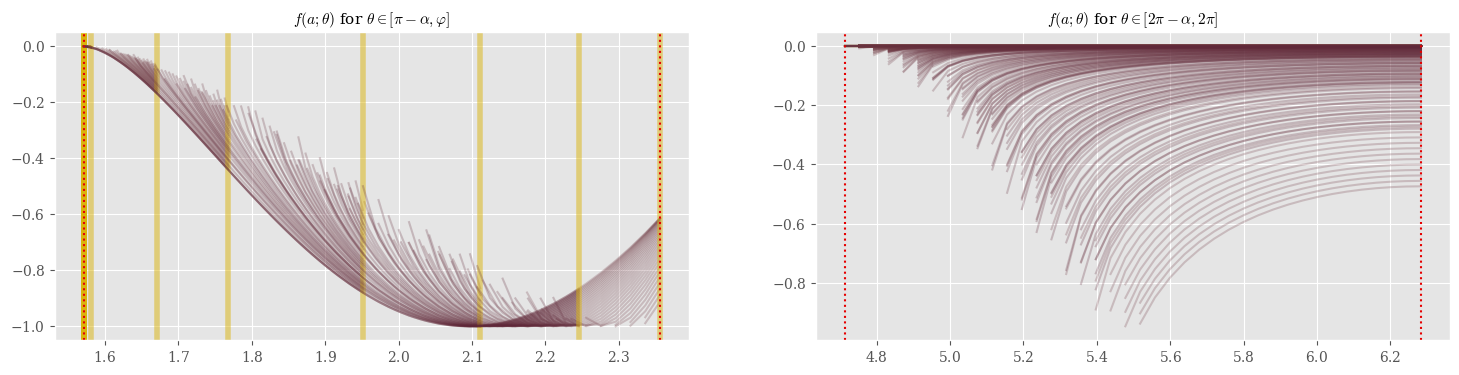

In [17]:
# Integration region
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (18,4))

i = 0
for ε in [mp.mpf('10') ** -a for a in np.arange(30,-1,-1)] + [0.2,0.4,0.6,0.8]:
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε) for λ in Λ]
    
    largest_φ = φ_from(A[-1], ε)
    Θ_range_1 = mp.linspace(mp.pi/n_2, largest_φ, 40)
    Θ_range_2 = mp.linspace(n_3 * mp.pi/n_2, n_2 * mp.pi, 40)
    
    for a in A[::3]:
        α = mp.asin(n_1/a)
        Θ_sub_range_1 = [x for x in Θ_range_1 if x >= mp.pi - α]
        ax[0].plot(Θ_sub_range_1, [f(a,x) for x in Θ_sub_range_1], color = colorFader('#ffe1a8','#723d46',i/30), alpha = 0.25)
        
        Θ_sub_range_2 = [x for x in Θ_range_2 if x >= n_2*mp.pi - α]
        ax[1].plot(Θ_sub_range_2, [f(a,x) for x in Θ_sub_range_2 ], color = colorFader('#ffe1a8','#723d46',i/30), alpha = 0.25)
    
    ax[0].axvline(x = largest_φ, color='xkcd:gold', linewidth=4.0, alpha = 0.5)
    i += 1
    
ax[0].set_title(r'$f(a;\theta)$ for $\theta \in [\pi-\alpha,\varphi]$', {'fontsize':11})
ax[0].axvline(x = mp.pi/2, color='xkcd:red', linestyle=':')
ax[0].axvline(x = n_3 * mp.pi/n_4, color='xkcd:red', linestyle=':')

ax[1].set_title(r'$f(a;\theta)$ for $\theta \in [2\pi-\alpha,2\pi]$', {'fontsize':11})
ax[1].axvline(x=n_3 * mp.pi/n_2, color='xkcd:red', linestyle=':')
ax[1].axvline(x=n_2 * mp.pi, color='xkcd:red', linestyle=':')
plt.show()

We observe that all the integration intervals are well defined. Moreover, the integral must be negative for all $a$.

In [21]:
# Numerical quadrature
def G_by_integral_C(a, ϕ, α):
    þ = mp.mpf('10')**-(mp.dps-4)    # Threshold for equality
    
    # Two intervals of existence
    if (ϕ < mp.pi - α) or mp.almosteq(ϕ, mp.pi - α, abs_eps = þ):
        A = n_0
    else:
        A = mp.quad(lambda θ: f(a, θ), [mp.pi - α, ϕ], method='gauss-legendre' )
    # Full integral
    A += mp.quad(lambda θ: f(a, θ), [n_2 * mp.pi - α, n_2 * mp.pi], method='gauss-legendre' )
    return A
def Test_Cn(a,ε):
    # Find angle
    θ = φ_from(a,ε)
    α = mp.asin(n_1/a)
    if a*a == n_1 + ε*ε:
        α = mp.pi/n_2 - mp.atan(ε)
    # Evaluate integral
    T = G_by_integral_C(a, θ, α)
    
    return T

The numerical integral is susceptible to numerical error. Hence, we increased the precision to 150 digits for the following plots. However, for $\varepsilon < 10^{-5}$, the numerical method fails again and we see that (under scaling) the curves no longer converge.

In [22]:
# Test
N = 50                                              # Number of points
Λ = mp.linspace(n_0, n_1, N)
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version

nA = np.arange(30,0,-1)[-8:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))

H_n_mp = np.empty([len(E_mp), N], 'object')

i = 0
for i in range(len(E_mp)):
    ε = E_mp[i]
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε)  for λ in Λ]
    H_n_mp[i] = [Test_Cn(a,ε) for a in A]    # Numeric

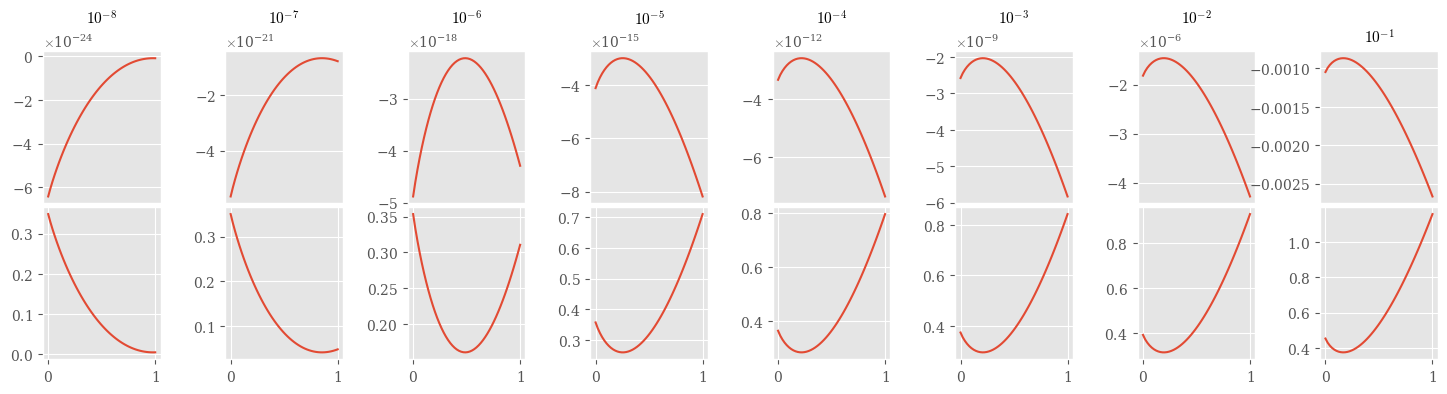

In [23]:
# Plot
fig, ax = plt.subplots(nrows=2, ncols=len(E_mp), figsize = (18,4))
i = 0
for i in range(len(E_mp)):
    ε = E_mp[i]
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε)  for λ in Λ]
    
    ax[i // 8,i % 8].plot(Λ_np, [x for x in H_n_mp[i]] )
    ax[1,i % 8].plot(Λ_np, [x/ (ε * ε * ε  * mp.log(ε) ) for x in H_n_mp[i]]  )
    ax[i // 8,i % 8].set_title(leg[i], {'fontsize':11})
    
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)
    ax[0,i % 8].set_xticks([])

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.025)

 Check range of $\{\Phi(\alpha), \Phi(\pi - \alpha),\Phi(2\pi - \alpha)\}$: $\Phi\left( \frac{\pi}{2} - \arctan \varepsilon, \frac{\pi}{2} \right) = \left[ \frac{\pi}{4}, \frac{\pi}{2} \right]$

In [24]:
Φ_πmα_1 = [[(n_2 * mp.asin(n_1/((n_1-λ) + λ * mp.sqrt(n_1+ε*ε)) ) + mp.pi)/n_4 for λ in Λ] for ε in mp.linspace(1e-10,1,10)]
#Φ_πmα_2 = [[ Φ((n_1-λ) + λ * mp.sqrt(n_1+ε*ε), mp.asin(n_1/((n_1-λ) + λ * mp.sqrt(n_1+ε*ε))) )  for λ in Λ] for ε in mp.linspace(1e-10,1,10)]
Φ_πmα_2 = [[ Φ((n_1-λ) + λ * mp.sqrt(n_1+ε*ε), n_2 * mp.pi - mp.asin(n_1/((n_1-λ) + λ * mp.sqrt(n_1+ε*ε))) )  for λ in Λ] for ε in mp.linspace(1e-10,1,10)]
np.asarray(Φ_πmα_1).max(), mp.pi/n_2, np.asarray(Φ_πmα_1).min(), n_3 * mp.pi / mp.mpf('8.0'), abs(np.asarray(Φ_πmα_1) - Φ_πmα_2).max()

(mpf('1.570796326794896619231321691639751442098584699687552910487472296153908203143104499314017412671058533991074043256641153323546922304784'),
 mpf('1.570796326794896619231321691639751442098584699687552910487472296153908203143104499314017412671058533991074043256641153323546922304784'),
 mpf('1.178097245096172464423491268729813581573938524765664682865604222115431152357328374485513059503293900493305532442480864992660191728593'),
 mpf('1.178097245096172464423491268729813581573938524765664682865604222115431152357328374485513059503293900493305532442480864992660191728593'),
 mpf('1.352487102214707389759608998412622085622355525398903130141935407187935086466960829518275184420757436976322511621129629506975471647104e-130'))

Where we recalled that $\Phi(\alpha) = \Phi(\pi - \alpha) = \Phi(2\pi - \alpha) = \dfrac{2\alpha + \pi}{4}$. Now, let's plot $G(a;\Phi(\alpha))$:

In [25]:
def G_mp_c(a,ϕ):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality

    '''
        Angular quantities
    '''
    cosϕ, cos2ϕ, sin2ϕ = mp.cos(ϕ), mp.cos(n_2 * ϕ), mp.sin(n_2 * ϕ)
    if (n_2 * ϕ == mp.pi):
        cosϕ, cos2ϕ, sin2ϕ = n_0, -n_1, n_0
    if (ϕ == n_0):
        cosϕ, cos2ϕ, sin2ϕ = n_1, n_1, n_0
    
    '''
        Special cases
    '''
    # G(1;ϕ)
    if (a == n_1):
        if cosϕ == n_0:
            return n_0
        else:
            G  = n_2 * mp.polylog(2, -mp.exp(2j * ϕ)).imag
            G += n_2 * (n_1 - mp.log( n_2 * abs(cosϕ) ) ) * sin2ϕ
            return G
    
    # G(a;π/2)
    '''if (n_2 * ϕ == mp.pi):
        G = (n_1 - a*a) * mp.pi
        if a > 1:
            G -= n_2 * mp.pi * mp.log(a)   # Im Li2(a) = -π log a  for a>1
        return G/(ε*ε*2*mp.log(ε)) if scale else G'''
    # G(a; 0)
    if ϕ == n_0:
        return n_0
    
    # G(a; (2α+π)/2 )
    if mp.almosteq(ϕ * n_4, n_2 * mp.asin(n_1/a) + mp.pi, abs_eps = þ):
        # Exact case
        α = mp.asin(n_1/a)
        # Dilog term
        z   = -a * mp.exp(2j * ϕ)
        T_1 = n_2 * mp.polylog(2, z).imag
        # Angular term
        T_2 = (n_1 - a*a) * α
        # Log term
        T_3 = (n_2 - mp.log(a*a - n_1)) * mp.sqrt(a*a - n_1)
        
        return T_1 + T_2 + T_3
    
    '''
        General case
    '''
    # Dilog term
    z   = -a * mp.exp(2j * ϕ)
    T_1 = n_2 * mp.polylog(2, z).imag
    
    # Angular term
    if sin2ϕ == n_0:
        α = n_0
    else:
        #α = mp.atan2(a * sin2ϕ, n_1 + a * cos2ϕ)
        #α = mp.atan( (a * sin2ϕ) / (n_1 + a * cos2ϕ))
        #mp.arg(1 + a * mp.exp(2j * ϕ))
        α = mp.arg(n_1 - z)
        #print(α)
    α = mp.arg(n_1 - z)
    T_2 = (n_1 - a*a) * (n_2 * ϕ - α)
    
    # Log term
    l_a = (a - n_1)*(a - n_1)  + n_4 * a * (cosϕ*cosϕ)   # stable version of n_1 + a*a + n_2 * a * cos2ϕ
    T_3 = a * (n_2 - mp.log(l_a) ) * sin2ϕ
    if sin2ϕ == n_0:
        T_3 = n_0
    
    # Collect terms:
    G  = T_1 + T_2 + T_3
    
    return G

In [26]:
nA = np.arange(30,0,-1)[-8:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))

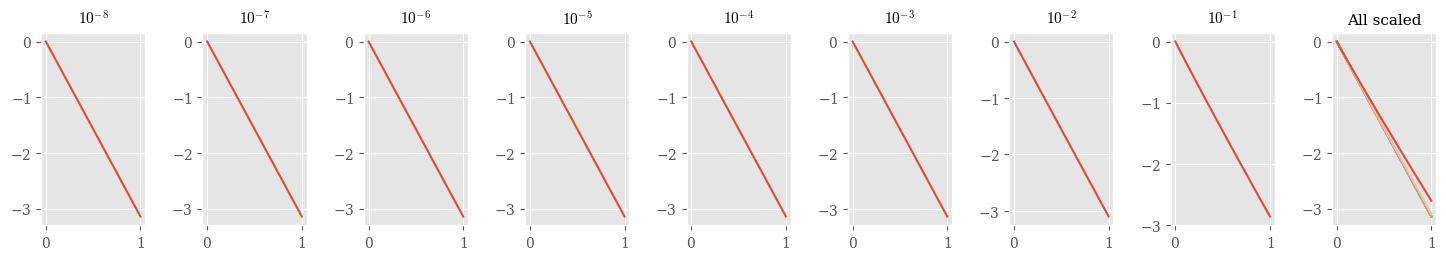

In [27]:
# Plot G(a, Φ(α))
fig, ax = plt.subplots(nrows=1, ncols=len(E_mp)+1, figsize = (18,2.5))
i = 0
for i in range(len(E_mp)):
    ε = E_np[i]
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε)  for λ in Λ]
    
    G_at_α = np.zeros(len(Λ), 'object')
    for j in range(N):
        a = A[j]
        α = mp.asin(n_1/a)
        ω = (n_2 * α + mp.pi)/n_4
        G_at_α[j] = G_mp_c(a,ω) / (ε * ε)
    
    ax[i].plot(Λ_np, [x for x in G_at_α] )
    ax[i].set_title(leg[i], {'fontsize':11})
    
    ax[-1].plot(Λ_np, [x for x in G_at_α] )
    ax[-1].set_title('All scaled', {'fontsize':11})
    
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.025)

For computing $G(a;\Phi(\varphi))$ here, we recall that at the righthandside limit $s(\varphi) = \varepsilon$, $L(\varphi) = -\dfrac{1}{\sqrt{ 1 + \varepsilon^2 }}$, and $\Phi(\varphi) = \frac{1}{2} \arccos L(\varphi) = \frac{\pi}{2} - \frac{1}{2}\arctan \varepsilon$

In [28]:
#[s(mp.sqrt(n_1 + ε*ε), φ_from(mp.sqrt(n_1 + ε*ε),ε)) for ε in E_mp]
print([ mp.nstr(Φ(mp.sqrt(n_1 + ε*ε), φ_from(mp.sqrt(n_1 + ε*ε),ε) ) - (mp.pi - mp.atan(ε))/n_2, 1)  for ε in E_mp])

['2.0e-124', '2.0e-125', '4.0e-126', '-7.0e-127', '3.0e-128', '3.0e-129', '7.0e-130', '0.0']


In [29]:
def Test_Ce(a,ε):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    
    '''
        Variable transformation
    '''
    # Get φ and map it through Φ
    θ = φ_from(a,ε)
    ϕ = Φ(a, θ)
    if mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):
        ϕ = (mp.pi - mp.atan(ε))/n_2    
    
    # α
    α = mp.asin(n_1/a)
    if mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):
        α = mp.pi/n_2 - mp.atan(ε)
    ω = (n_2 * α + mp.pi)/n_4
    
    '''
        Functional evaluation
    '''
    T  = G_mp_c(a,ϕ) - G_mp_c(a,ω)                # This one coincides with the quadrature
    T += -2*mp.pi*mp.log(a) - G_mp_c(a,ω)         # Principal boundary value (approached from the upper half-plane):  2 im Li_2 (a + 0i) = -2\pi a
    #T = (1-a*a)*mp.pi - G_mp_c(a,ω)              # <- This is a good approximation as well
    
    return T

In [30]:
# Test
N = 50                                              # Number of points
Λ = mp.linspace(n_0, n_1, N)
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version

nA = np.arange(30,0,-1)[-8:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))

H_e_mp = np.empty([len(E_mp), N], 'object')

for i in range(len(E_mp)):
    ε = E_mp[i]
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε)  for λ in Λ]
    H_e_mp[i] = [Test_Ce(a,ε) for a in A]    # Exact

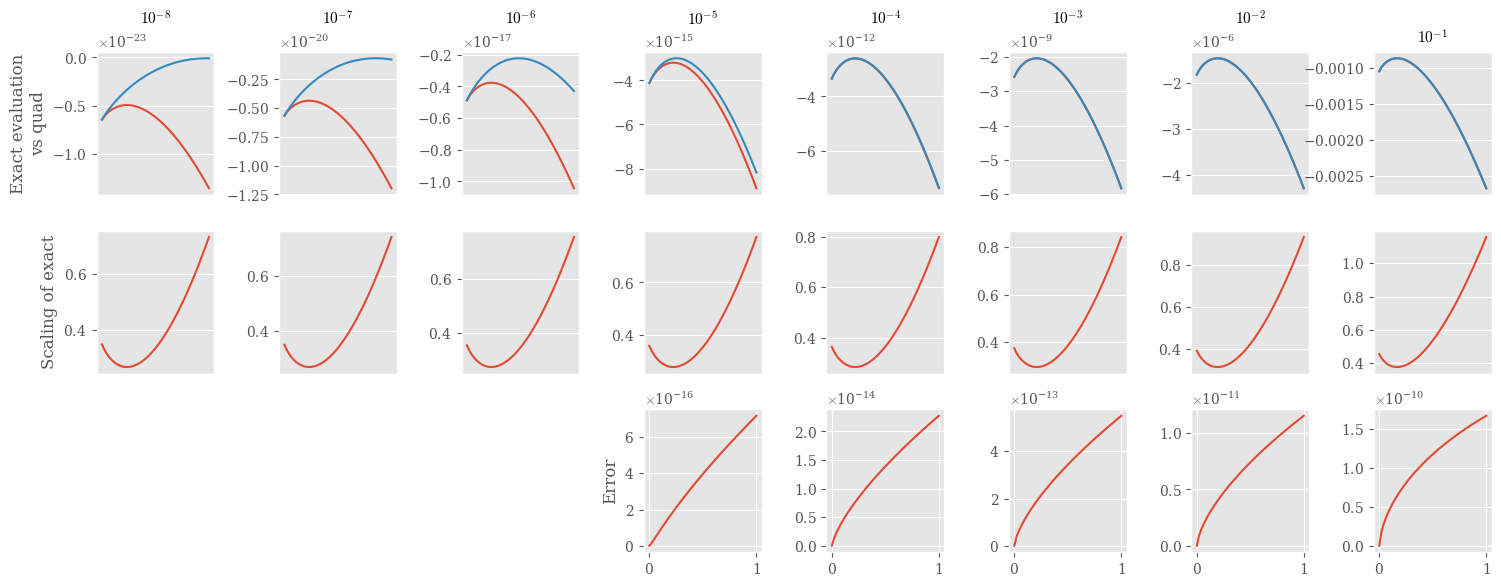

In [31]:
# Plot
fig, ax = plt.subplots(nrows=3, ncols=len(E_mp), figsize = (18,6.5))
i = 0
for i in range(len(E_mp)):
    ε = E_mp[i]
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε)  for λ in Λ]
    
    ax[i // 8,i % 8].plot(Λ_np, [x for x in H_e_mp[i]] )
    ax[i // 8,i % 8].plot(Λ_np, [x for x in H_n_mp[i]] )
    
    ax[1,i % 8].plot(Λ_np, [x/ (ε * ε * ε  * mp.log(ε) ) for x in H_e_mp[i]]  )
    if i > 2:
        ax[2,i % 8].plot(Λ_np, [x for x in abs(H_e_mp - H_n_mp)[i]]  )
    ax[i // 8,i % 8].set_title(leg[i], {'fontsize':11})
    
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)
    ax[0,i % 8].set_xticks([])
    ax[1,i % 8].set_xticks([])
    
[ax[2,i].set_axis_off() for i in range(3)]
ax[0,0].set_ylabel('Exact evaluation\nvs quad')
ax[1,0].set_ylabel('Scaling of exact')
ax[2,3].set_ylabel('Error')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.25)

---

In [32]:
E_mp = mp.linspace(mp.mpf('0.1'), n_1, 8)
i = 0
for i in range(len(E_mp)):
    ε = E_mp[i]
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε)  for λ in Λ]
    H_n_mp[i] = [Test_Cn(a,ε) for a in A]    # Numeric
    H_e_mp[i] = [Test_Ce(a,ε) for a in A]    # Exact

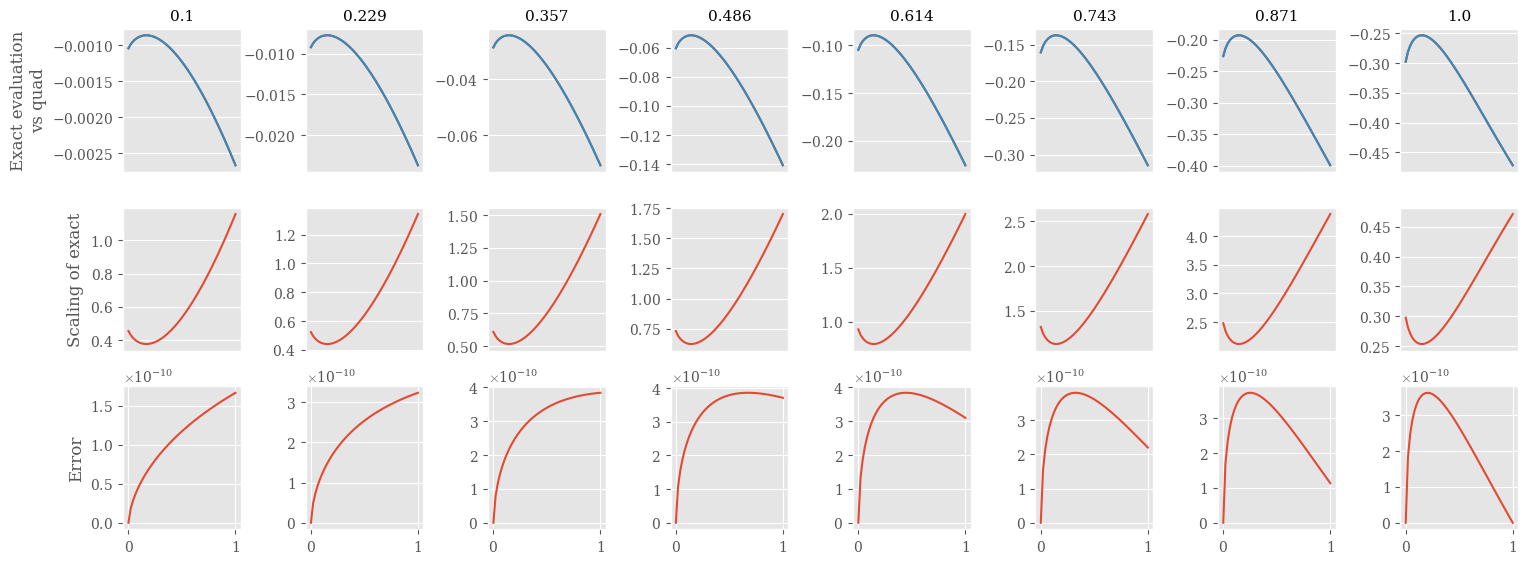

In [33]:
# Plot
fig, ax = plt.subplots(nrows=3, ncols=len(E_mp), figsize = (18,6.5))
i = 0
for i in range(len(E_mp)):
    ε = E_mp[i]
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε)  for λ in Λ]
    
    ax[i // 8,i % 8].plot(Λ_np, [x for x in H_e_mp[i]] )
    ax[i // 8,i % 8].plot(Λ_np, [x for x in H_n_mp[i]] )
    
    ax[1,i % 8].plot(Λ_np, [x/ (ε * ε * ε * mp.log(ε) if ε < n_1 else -n_1  ) for x in H_e_mp[i]]  )
    ax[2,i % 8].plot(Λ_np, [x for x in abs(H_e_mp - H_n_mp)[i]]  )
    ax[i // 8,i % 8].set_title(mp.nstr(ε,3), {'fontsize':11})
    
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)
    ax[0,i % 8].set_xticks([])
    ax[1,i % 8].set_xticks([])
    
ax[0,0].set_ylabel('Exact evaluation\nvs quad')
ax[1,0].set_ylabel('Scaling of exact')
ax[2,0].set_ylabel('Error')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.25)

# Case $a \in \left[\sqrt{1+\varepsilon^2}, 1+\varepsilon\right]$ with $\varphi \in \left[\arccos -\frac{\varepsilon}{\sqrt{1+\varepsilon^2}}, \pi \right]$

Here $\alpha = \arcsin \frac{1}{a} \in \left[ \frac{\pi}{6}, \frac{\pi}{2} - \arctan \varepsilon \right]$. There is one relevant interval of continuity for $f$: $[\varphi + \pi , 2\pi]$. 
We aim then to showcase
\begin{align*}
    G(a,\Phi(2\pi)) - G(a,\Phi(\varphi+\pi)) &=
    G(a,\pi/2) - G(a,\Phi(\varphi+\pi)) 
    \\
    &= g(a;2\pi) - g(a;\varphi+\pi)  = \int_{\varphi+\pi}^{2\pi} s^2(\theta) \big( \log( s^2(\theta) ) - 1 \big) \dif \theta.
\end{align*}

Moreover, at the boundary $a = \sqrt{1+\varepsilon^2}$ yields $\varphi = \pi - \alpha$ and here $\varphi = \frac{\pi}{2} + \arctan \varepsilon$ and $\alpha = \frac{\pi}{2} - \arctan \varepsilon$. Thus, this integral coincides with the second integral in the previous set of experiments.

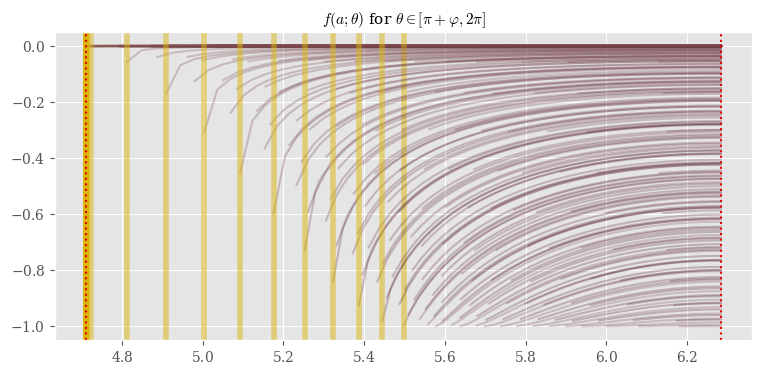

In [34]:
# Integration region
fig, ax = plt.subplots(nrows=1, ncols=1, figsize = (9,4))

i = 0
for ε in [mp.mpf('10') ** -a for a in np.arange(30,-1,-1)] + mp.linspace(mp.mpf('0.2'), mp.mpf('0.9'), 8):
    A = [(n_1-λ) * mp.sqrt(n_1+ε*ε) + λ * (n_1+ε) for λ in Λ]
    
    smallest_φ = φ_from(A[0], ε) + mp.pi
    Θ_range = mp.linspace(smallest_φ, mp.pi*n_2, 40)
    
    for a in A[::3]:
        ω = φ_from(a, ε) + mp.pi
        Θ_sub_range = [x for x in Θ_range if x >= ω]
        ax.plot(Θ_sub_range, [f(a,x) for x in Θ_sub_range], color = colorFader('#ffe1a8','#723d46',i/30), alpha = 0.25)
        
    
    ax.axvline(x = smallest_φ, color='xkcd:gold', linewidth=4.0, alpha = 0.5)
    i += 1
    
ax.set_title(r'$f(a;\theta)$ for $\theta \in [\pi+\varphi, 2\pi]$', {'fontsize':11})
ax.axvline(x = n_3 * mp.pi/n_2, color='xkcd:red', linestyle=':')
ax.axvline(x = n_2 * mp.pi, color='xkcd:red', linestyle=':')
plt.show()

In [35]:
mp.dps = 50 #2*50 + 30
mp.mp.dps = 50 #2*50 + 30
print(mp.mp)
'''mp.dps = 2*50 + 30
mp.mp.dps = 2*50 + 30
print(mp.mp)'''

Mpmath settings:
  mp.prec = 169               [default: 53]
  mp.dps = 50                 [default: 15]
  mp.trap_complex = False     [default: False]


'mp.dps = 2*50 + 30\nmp.mp.dps = 2*50 + 30\nprint(mp.mp)'

We observe that all the integration intervals are well defined. Moreover, the integral must be negative for all $a$.

In [36]:
# Numerical quadrature
def G_by_integral_D(a, ϕ):
    þ = mp.mpf('10')**-(mp.dps-4)    # Threshold for equality
    
    # One interval of existence
    if mp.almosteq(ϕ, mp.pi, abs_eps = þ):
        A = n_0
    else:
        A = mp.quad(lambda θ: f(a, θ), [mp.pi + ϕ, n_2*mp.pi], method='gauss-legendre' )
    return A
def Test_Dn(a,ε):
    # Find angle
    θ = φ_from(a,ε)
    # Evaluate integral
    T = G_by_integral_D(a, θ)
    
    return T

In [37]:
# Exact evaluation
def Test_De(a,ε):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    
    '''
        Variable transformation
    '''
    # Get φ and map it through Φ
    θ = φ_from(a,ε)
    ϕ = Φ(a, θ + mp.pi)
    if mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):
        ϕ = (mp.pi - mp.atan(ε))/n_2                # φ = π + atan ε -> Φ(φ+π) = Φ(2π-α) = (π - atan ε)/2
        
    '''
        Functional evaluation
    '''
    #T = G_mp_c(a,mp.pi/n_2) - G_mp_c(a,ϕ)          # This one does not coincide with the quadrature
    T  = -2*mp.pi*mp.log(a) - G_mp_c(a,ϕ)           # Principal boundary value (approached from the upper half-plane):  2 im Li_2 (a + 0i) = -2\pi a
    if mp.almosteq(a, n_1 + ε, abs_eps = þ):
        T = n_0                                     # Φ(φ+π) = π/2 and integral cancels out
    
    return T

The numerical integral is handles well the error and we observe a scaling of $\varepsilon^2 \log \varepsilon^2$.

In [38]:
# Test
N = 50                                              # Number of points
Λ = mp.linspace(n_0, n_1, N)
Λ_np = np.fromiter((np.float64(x) for x in Λ), dtype=np.float64, count=N)    # NumPy version

nA = np.arange(30,0,-1)[-8:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))

H_n_mp = np.empty([len(E_mp), N], 'object')
H_e_mp = np.empty([len(E_mp), N], 'object')

i = 0
for i in range(len(E_mp)):
    ε = E_mp[i]
    A = [(n_1-λ)*mp.sqrt(n_1+ε*ε) + λ * (n_1+ε)  for λ in Λ]
    H_n_mp[i] = [Test_Dn(a,ε) for a in A]    # Numeric
    H_e_mp[i] = [Test_De(a,ε) for a in A]    # Exact

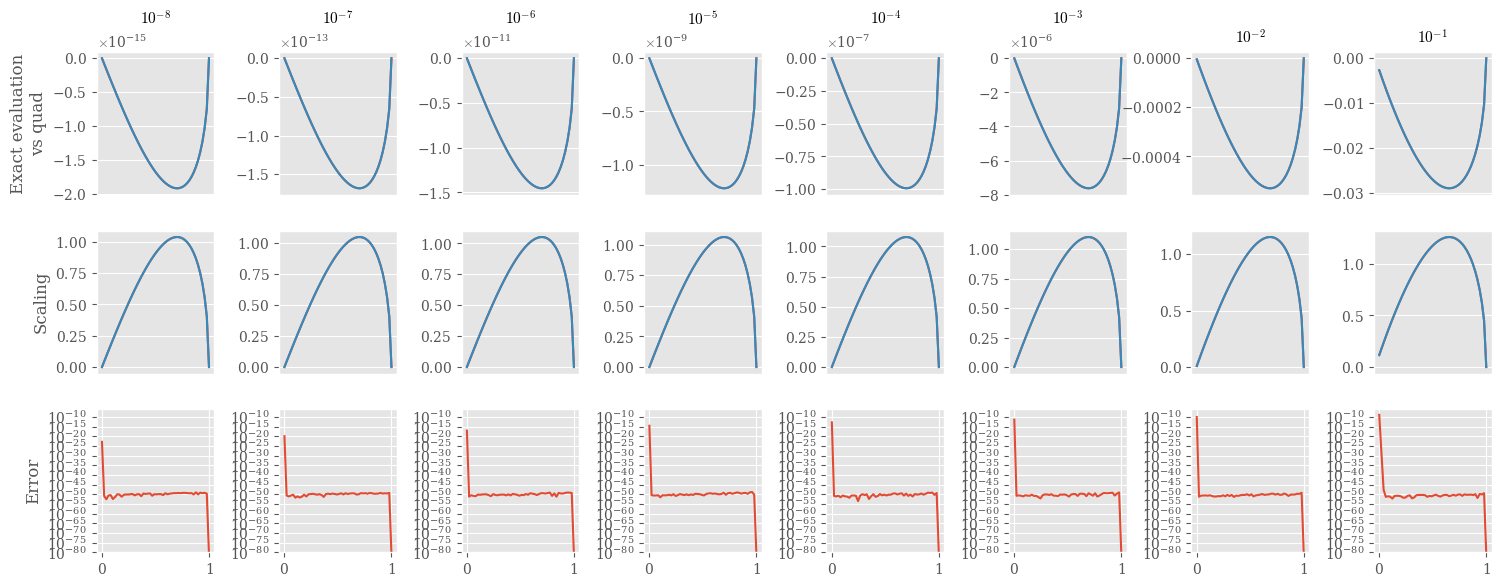

In [39]:
# Plot
fig, ax = plt.subplots(nrows=3, ncols=len(E_mp), figsize = (18,6.5))
i = 0
for i in range(len(E_mp)):
    ε = E_mp[i]
    A = [(n_1-λ) + λ * mp.sqrt(n_1+ε*ε)  for λ in Λ]
    
    ax[i // 8,i % 8].plot(Λ_np, [x for x in H_e_mp[i]] )
    ax[i // 8,i % 8].plot(Λ_np, [x for x in H_n_mp[i]] )
    
    ax[1,i % 8].plot(Λ_np, [x/ (ε * ε * mp.log(ε) ) for x in H_e_mp[i]]  )
    ax[1,i % 8].plot(Λ_np, [x/ (ε * ε * mp.log(ε) ) for x in H_n_mp[i]]  )
    ax[2,i % 8].plot(Λ_np, [x for x in abs(H_e_mp - H_n_mp)[i]]  )
    ax[i // 8,i % 8].set_title(leg[i], {'fontsize':11})
    
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)
    ax[0,i % 8].set_xticks([])
    ax[1,i % 8].set_xticks([])
    ax[2,i % 8].set_yscale('symlog', linthresh = 1e-80)
    ax[2,i % 8].set_ylim([1e-80,1e-6])
    
#[ax[2,i].set_axis_off() for i in range(3)]
ax[0,0].set_ylabel('Exact evaluation\nvs quad')
ax[1,0].set_ylabel('Scaling')
ax[2,0].set_ylabel('Error')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.25)

---

# Evaluation $[1-\varepsilon,1+\varepsilon]$

Let us now concatenate our previous results into a single-call function, which computes the function $F_\varepsilon$ in high precision:

In [40]:
def s(a, θ):
    # Stable computation of s(θ)
    sinθ, cosθ = mp.sin(θ), mp.cos(θ)
    if θ == n_0:
        sinθ, cosθ = n_0, n_1
    elif n_2 * θ == mp.pi:
        sinθ, cosθ = n_1, n_0
    elif n_2 * θ == mp.mpf('3.0') * mp.pi:
        sinθ, cosθ = -n_1, n_0
    elif θ == mp.pi:
        sinθ, cosθ = n_0, -n_1
    elif θ == n_2 * mp.pi:
        sinθ, cosθ = n_0, n_1
    elif (mp.sin(θ) * a == n_1) and (a > n_1):
        if cosθ < n_0:
            sinθ, cosθ = n_1/a, -mp.sqrt(a*a-n_1)/a            # π - α
        else:
            sinθ, cosθ = n_1/a,  mp.sqrt(a*a-n_1)/a            # α
    elif (mp.sin(θ) * a == -n_1) and (a > n_1):
        sinθ, cosθ = -n_1/a, mp.sqrt(a*a-n_1)/a                # 2π - α
        
        
        
    R = n_1 - (a*a)*(sinθ * sinθ)
    if (abs(mp.sin(θ)) * a == n_1) and (a>n_1):
        R = n_0
    
    # Trim under precision
    if R < -mp.mpf('10')**-(mp.dps-2):
        return n_0
        
    # Clip and process
    if abs(R) <= mp.mpf('10')**-(mp.dps-2):
        s_out = -a * cosθ
    else:
        s_out = -a * cosθ + mp.sqrt(R)    
    
    if a == n_1:
        if cosθ >= n_0:
            s_out = n_0
        else:
            s_out = -n_2 * cosθ
    return s_out
def f(a,θ):
    s_aθ = s(a, θ)
    if s_aθ == n_0:
        return n_0
    return (s_aθ * s_aθ) * (n_2 * mp.log(abs(s_aθ)) - n_1)
def φ_from(a,ε):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    
    cos  = n_1 - a*a - ε*ε
    cos /= n_2 * a * ε
    
    # Special cases
    if a == n_1 - ε:              # cos φ = 1
        return n_0
    elif a == n_1 + ε:            # cos φ = -n_1
        return mp.pi
    elif mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):    #a*a == n_1 + ε*ε:        # cos φ = -ε/mp.sqrt(1 + ε^2)
        #return mp.acos(-ε/mp.sqrt(n_1 + ε*ε))
        return mp.atan(ε) + mp.pi/n_2
    elif mp.almosteq(a*a, n_1 - ε*ε, abs_eps = þ):    #a*a == n_1 - ε*ε:        # cos φ = n_0
        return mp.pi/n_2
    elif a == n_1:                # cos φ = -ε/2
        return mp.acos(-ε/n_2)
        
    return mp.acos(cos)
def Φ(a, θ):
    '''
        Variable transformation
    '''
    sθ = s(a, θ)
    Lθ = (sθ * sθ - n_1 - a*a)/(n_2 * a)        # Range [-1,1]
    if a == n_1:
        Lθ = (sθ * sθ / n_2) - n_1
    ϕ  = mp.acos(Lθ) / n_2                      # Range [0,π/2]
    return ϕ

In [41]:
# High-precision G
def G_mp(a,ϕ):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    
    '''
        Angular quantities
    '''
    cosϕ, cos2ϕ, sin2ϕ = mp.cos(ϕ), mp.cos(n_2 * ϕ), mp.sin(n_2 * ϕ)
    if (n_2 * ϕ == mp.pi):
        cosϕ, cos2ϕ, sin2ϕ = n_0, -n_1, n_0
    if (ϕ == n_0):
        cosϕ, cos2ϕ, sin2ϕ = n_1,  n_1, n_0
    
    '''
        Special cases
    '''
    # G(1;ϕ)
    if (a == n_1):
        if cosϕ == n_0:
            return n_0
        else:
            G  = n_2 * mp.polylog(2, -mp.exp(2j * ϕ)).imag
            G += n_2 * (n_1 - mp.log( n_2 * abs(cosϕ) ) ) * sin2ϕ
            return G
    
    # G(a;π/2)
    '''if mp.almosteq(n_2 * ϕ, mp.pi, abs_eps = þ):
        if a <= 1:
            G = (n_1 - a*a) * mp.pi
        else:
            G = -n_2 * mp.pi * mp.log(a)
        return G'''
    # G(a; 0)
    if ϕ == n_0:
        return n_0
    
    # G(a; (2α+π)/2 )
    if a > n_1:
        α = mp.asin(n_1/a)
        # Exact case
        if mp.almosteq(ϕ * n_4, n_2 * α + mp.pi, abs_eps = þ):
            # Dilog term
            z   = -a * mp.exp(2j * ϕ)
            T_1 = n_2 * mp.polylog(2, z).imag
            # Angular term
            T_2 = (n_1 - a*a) * α
            # Log term
            T_3 = (n_2 - mp.log(a*a - n_1)) * mp.sqrt(a*a - n_1)

            return T_1 + T_2 + T_3
    
    '''
        General case
    '''
    # Dilog term
    z   = -a * mp.exp(2j * ϕ)
    T_1 = n_2 * mp.polylog(2, z).imag
    
    # Angular term
    ang = mp.arg(n_1 - z)
    T_2 = (n_1 - a*a) * (n_2 * ϕ - ang)
    
    # Log term
    l_a = (a - n_1)*(a - n_1)  + n_4 * a * (cosϕ*cosϕ)   # stable version of n_1 + a*a + n_2 * a * cos2ϕ
    T_3 = a * (n_2 - mp.log(l_a) ) * sin2ϕ
    if sin2ϕ == n_0:
        T_3 = n_0
    
    # Collect terms:
    G  = T_1 + T_2 + T_3
    
    return G

In [42]:
def F_eval(a,ε):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    '''
        Variable transformation
    '''
    θ  = φ_from(a,ε)
    ϕ  = Φ(a,θ)
    
    if (a > n_1):
        # α activates
        α = mp.asin(n_1/a)
        
        # Exact evaluation at breaking point
        if mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):
            ϕ = (mp.pi - mp.atan(ε))/n_2
            α = mp.pi/n_2 - mp.atan(ε)
        
        # Auxiliary angle = Φ(α)
        ω = (n_2 * α + mp.pi)/n_4
    
    '''
        Functional evaluation
    '''
    if mp.almosteq(a, n_1-ε, abs_eps = þ):
        # At interval extremes, the mass is zero
        T = n_0                               # π ε (2 - ε) cancels out the quadratic term
    elif (a > n_1 - ε) and (a < n_1):
        # One continuous interval of existence
        T = G_mp(a,ϕ) - (n_1 - a*a) * mp.pi
    elif mp.almosteq(a, n_1, abs_eps = þ):
        # One functional evaluation
        T = G_mp(n_1, Φ(n_1, φ_from(n_1,ε) ) )
    elif (a > n_1) and (a*a < n_1 + ε*ε):
        # Two intervals of existence and correct branch selection
        T = G_mp(a,ϕ) - (n_2 * G_mp(a,ω)) - (n_2 * mp.pi * mp.log(a))
    elif (a*a >= n_1 + ε*ε):
        # One interval of continuity, no α involved
        ϕ = Φ(a, θ + mp.pi)
        if mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):
            ϕ = (mp.pi - mp.atan(ε))/n_2
        # Principal boundary value (approached from the upper half-plane):  2 im Li_2 (a + 0i) = -2\pi a
        T  = -2*mp.pi*mp.log(a) - G_mp(a,ϕ)
        if mp.almosteq(a, n_1 + ε, abs_eps = þ):
            T = n_0                                     # Φ(φ+π) = π/2 and integral cancels out in the right branch (see previous case)
    
    # Scale
    T /= mp.pi * mp.mpf('8.0')
    
    return T

In [43]:
mp.dps = 2*50 + 30
mp.mp.dps = 2*50 + 30
print(mp.mp)

Mpmath settings:
  mp.prec = 435               [default: 53]
  mp.dps = 130                [default: 15]
  mp.trap_complex = False     [default: False]


In [44]:
nA = np.arange(30,0,-1)[::4]#[-8:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))

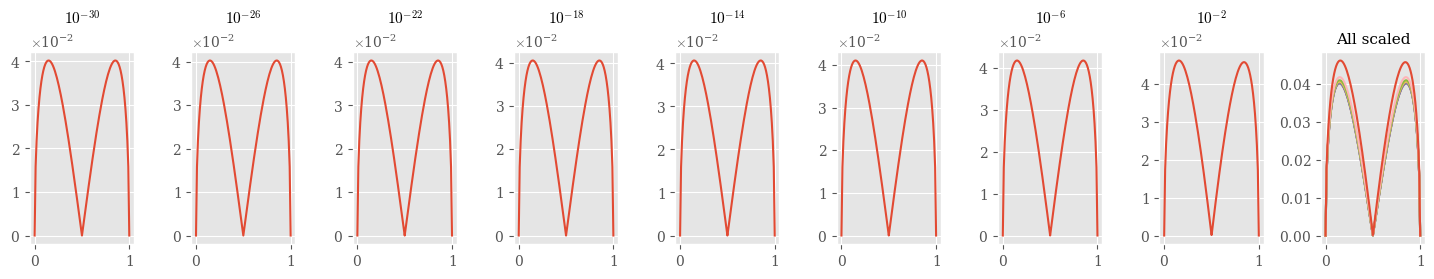

In [45]:
# Plot F(a)
fig, ax = plt.subplots(nrows=1, ncols=len(E_mp)+1, figsize = (18,2.5))
i = 0
for i in range(len(E_mp)):
    ε = E_np[i]
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, n_1/n_2, N) + mp.linspace(n_1/n_2, λₓ, N)[1:-1] + mp.linspace(λₓ, n_1, N)
    A = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    
    f_a = [F_eval( a,ε)/(ε*ε * mp.log(ε)) for a in A]
    ax[i].plot(Λ, f_a)
    ax[i].set_title(leg[i], {'fontsize':11})
    
    ax[-1].plot(Λ, f_a )
    ax[-1].set_title('All scaled', {'fontsize':11})
    
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)
    ax[i].ticklabel_format(axis='both', style='sci', scilimits=(0,0))

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.025)

In [46]:
from matplotlib.colors import to_hex, to_rgb
def colorFader(c1,c2,mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    c1 = np.array(to_rgb(c1))
    c2 = np.array(to_rgb(c2))
    return to_hex((1-mix)*c1 + mix*c2)
plt.style.use('default')
rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

In [47]:
nA = np.arange(30,0,-1)[::]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))

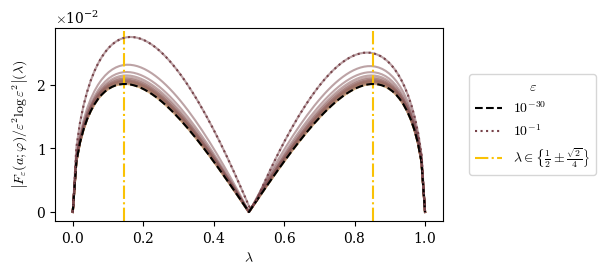

In [149]:
# Plot F(a)
f_s = []
plt.figure(figsize=(5,2.5))
for i in range(len(E_mp)):
    ε = E_np[i]
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, n_1/n_2, N) + mp.linspace(n_1/n_2, λₓ, N)[1:-1] + mp.linspace(λₓ, n_1, N)
    A = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    
    f_a = [F_eval( a,ε)/(ε*ε * mp.log(ε*ε)) for a in A]
    c_s = abs(np.asarray(f_a) - f_a[::-1]).max()
    f_s.append( c_s )    # Check symmetry
    
    plt.plot(Λ, f_a, color = colorFader('#ffe1a8','#723d46',i/len(E_mp)), alpha = 0.5, zorder = 1 )
    
    if i == 0:
        plt.plot(Λ, f_a, color = 'xkcd:black', linestyle = '--', label = leg[i], zorder = 3 )
    if i == len(E_mp)-1:
        plt.plot(Λ, f_a, color = colorFader('#ffe1a8','#723d46',i/len(E_mp)), linestyle = 'dotted', label = leg[i], zorder = 3 )
    
    
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)
    plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
    
plt.ylabel(r'$\left| F_\varepsilon (a;\varphi) / \varepsilon^2 \log \varepsilon^2 \right| (\lambda)$')
plt.xlabel(r'$\lambda$')

plt.axvline(x=0.5 - np.sqrt(2) * 0.25, color='xkcd:goldenrod', linestyle = '-.') # Max 1
plt.axvline(x=0.5 + np.sqrt(2) * 0.25, color='xkcd:goldenrod', linestyle = '-.', label = r'$\lambda \in \left\{ \frac{1}{2} \pm \frac{\sqrt{2}}{4} \right\}$') # Max 2

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.025)
#plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncols = 4, reverse = False, title = r'$\varepsilon$')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title = r'$\varepsilon$')

# –––––––– Store –––––––– #
plt.savefig('F_plots.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

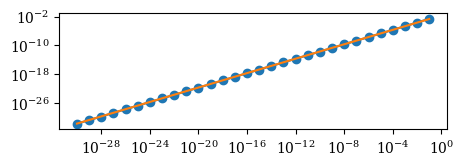

In [135]:
# Convergence
plt.figure(figsize = (5,1.5))
plt.scatter(E_np, f_s)
plt.plot(E_np, f_s)
plt.plot(E_np, E_np * 0.022)
plt.yscale('log')
plt.xscale('log')

In [126]:
x = np.fromiter((np.float64(mp.log(x)) for x in E_mp), dtype=np.float64, count=len(E_mp))
y = np.fromiter((np.float64(mp.log(x)) for x in f_s), dtype=np.float64,  count=len(f_s))

In [127]:
fitting = np.linalg.lstsq(np.stack((x, np.ones_like(x)), axis=1), y)

In [132]:
fitting[0], np.exp(fitting[0][1])

(array([ 1.00175871, -3.81050062]), np.float64(0.02213709396155221))

In [147]:
abs((E_np * 0.022) - f_s).max()

mpf('0.000436381919558015092964263529524742785724952451692458365111647728120686559386924265830889656352943543959610013818574313087066248327365')

---

# Extra: asymptotics of $\varphi$

In [55]:
nA = np.arange(30,0,-1)[::4]#[-8:]
E_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
E_np = np.fromiter((np.float64(x) for x in E_mp), dtype=np.float64, count=len(E_mp))

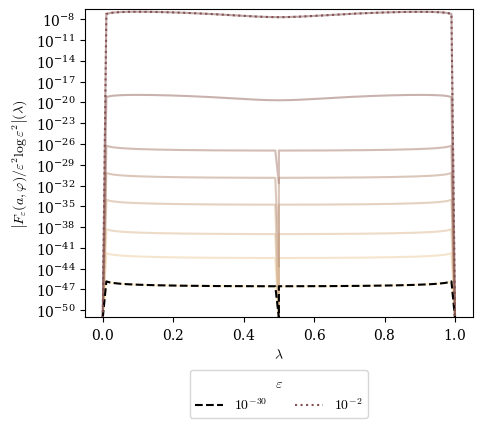

In [56]:
# Plot φ(a)
e_a = []

plt.figure(figsize=(5,4))
for i in range(len(E_mp)):
    ε = E_np[i]
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, n_1/n_2, N) + mp.linspace(n_1/n_2, λₓ, N)[1:-1] + mp.linspace(λₓ, n_1, N)
    A = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    
    f_a = np.asarray([φ_from(a,ε) for a in A])
    f_b = np.asarray([mp.acos(n_1-n_2*λ) + mp.sqrt(λ * (n_1-λ)) * ε + n_3 * (n_1 - n_2*λ) * mp.sqrt(λ*(n_1-λ)) * ε* ε / n_4 for λ in Λ])
    plt.plot(Λ, abs(f_a - f_b), color = colorFader('#ffe1a8','#723d46',i/len(E_mp)), alpha = 0.5, zorder = 1 )
    
    if i == 0:
        plt.plot(Λ, abs(f_a-f_b), color = 'xkcd:black', linestyle = '--', label = leg[i], zorder = 3 )
    if i == len(E_mp)-1:
        plt.plot(Λ, f_a-f_b, color = colorFader('#ffe1a8','#723d46',i/len(E_mp)), linestyle = 'dotted', label = leg[i], zorder = 3 )
    
    e_a.append(abs(f_a-f_b).max())
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)
    plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
    
plt.ylabel(r'$\left| F_\varepsilon (a,\varphi) / \varepsilon^2 \log \varepsilon^2 \right| (\lambda)$')
plt.xlabel(r'$\lambda$')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.025)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncols = 4, reverse = False, title = r'$\varepsilon$')
plt.yscale('symlog', linthresh=1e-50)
plt.ylim([1e-51,3e-7])
# –––––––– Store –––––––– #
#plt.savefig('F_plots.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

---